# 🏭 Manufacturing Equipment Output Prediction

## Data Science Capstone Project — Linear Regression

### Project Objective
The objective of this project is to predict the hourly production output (`Parts_Per_Hour`) of a plastic injection molding machine using machine operating parameters, environmental conditions, operator experience, maintenance information, and categorical manufacturing factors.

The analysis focuses on:
- Understanding the manufacturing dataset and its quality
- Exploring relationships between operating conditions and production output
- Preparing numerical and categorical features using a reproducible preprocessing pipeline
- Training a Linear Regression model
- Comparing **training and testing performance**
- Analyzing prediction errors and residuals
- Interpreting model coefficients
- Translating the findings into practical manufacturing insights and recommendations

> **Note:** FastAPI and Docker deployment are outside the scope of this notebook and can be handled as a separate deployment stage.

## Step 1: Import Libraries and Load the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load dataset
df = pd.read_csv("manufacturing_dataset_1000_samples.csv")

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

display(df.head())

Dataset loaded successfully.
Rows: 1000
Columns: 19


,Timestamp,Injection_Temperature,Injection_Pressure,Cycle_Time,Cooling_Time,Material_Viscosity,Ambient_Temperature,Machine_Age,Operator_Experience,Maintenance_Hours,Shift,Machine_Type,Material_Grade,Day_of_Week,Temperature_Pressure_Ratio,Total_Cycle_Time,Efficiency_Score,Machine_Utilization,Parts_Per_Hour
0,2023-01-01 00:00:00,221.0,136.0,28.7,13.6,375.5,28.0,3.8,11.2,64,Evening,Type_B,Economy,Thursday,1.625,42.3,0.063,0.510,36.5
1,2023-01-01 01:00:00,213.3,128.9,34.5,14.0,215.8,22.6,6.8,6.3,58,Night,Type_A,Standard,Wednesday,1.655,48.5,0.037,0.389,29.9
2,2023-01-01 02:00:00,222.8,115.9,19.9,9.5,307.0,25.3,4.2,9.6,47,Day,Type_A,Standard,Monday,1.922,29.4,0.061,0.551,56.9
3,2023-01-01 03:00:00,233.3,105.3,39.2,13.1,137.8,26.0,9.2,8.6,49,Evening,Type_A,Premium,Saturday,2.215,52.3,0.054,0.293,31.0
4,2023-01-01 04:00:00,212.2,125.5,45.0,9.9,298.2,23.6,6.2,23.0,49,Night,Type_B,Premium,Monday,1.691,54.9,0.145,0.443,15.0


## Step 2: Data Exploration and Understanding

### 2.1 Dataset Structure and Summary Statistics

In [2]:
print("Dataset Shape:", df.shape)

print("\nData Types:")
display(df.dtypes.to_frame("Data Type"))

print("\nSummary Statistics:")
display(df.describe(include="all").T)

Dataset Shape: (1000, 19)

Data Types:


,Data Type
Timestamp,object
Injection_Temperature,float64
Injection_Pressure,float64
Cycle_Time,float64
Cooling_Time,float64
Material_Viscosity,float64
Ambient_Temperature,float64
Machine_Age,float64
Operator_Experience,float64
Maintenance_Hours,int64



Summary Statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Timestamp,1000,1000,2023-01-01 00:00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Injection_Temperature,1000.0,NaN,NaN,NaN,215.3159,11.995507,180.0,207.2,215.3,222.8,300.0
Injection_Pressure,1000.0,NaN,NaN,NaN,116.075,14.667246,80.0,105.9,115.95,125.925,150.0
Cycle_Time,1000.0,NaN,NaN,NaN,35.8517,8.35349,16.3,28.8,36.85,45.0,60.0
Cooling_Time,1000.0,NaN,NaN,NaN,11.9232,2.30429,8.0,10.275,11.9,13.5,19.9
Material_Viscosity,980.0,NaN,NaN,NaN,251.630714,73.348695,104.6,200.9,242.7,295.3,1000.0
Ambient_Temperature,980.0,NaN,NaN,NaN,22.941224,2.773712,18.0,20.8,22.9,25.1,28.0
Machine_Age,1000.0,NaN,NaN,NaN,7.8559,3.900798,1.0,4.7,7.9,11.1,15.0
Operator_Experience,980.0,NaN,NaN,NaN,30.795204,27.684769,1.0,9.8,22.1,43.425,120.0
Maintenance_Hours,1000.0,NaN,NaN,NaN,50.58,16.014558,26.0,45.0,50.0,55.0,500.0


### 2.2 Business Meaning of the Variables

| Variable | Business Meaning |
|---|---|
| `Timestamp` | Date and time when the manufacturing record was captured. |
| `Injection_Temperature` | Temperature at which material is injected into the mold. |
| `Injection_Pressure` | Pressure used during material injection. |
| `Cycle_Time` | Time required for a complete production cycle. |
| `Cooling_Time` | Time spent cooling the molded part. |
| `Material_Viscosity` | Measure of material flow characteristics. |
| `Ambient_Temperature` | Temperature of the surrounding production environment. |
| `Machine_Age` | Age of the manufacturing machine. |
| `Operator_Experience` | Experience level of the operator. |
| `Maintenance_Hours` | Maintenance time associated with the machine. |
| `Shift` | Production shift, such as Day, Evening, or Night. |
| `Machine_Type` | Type/category of manufacturing machine. |
| `Material_Grade` | Grade of material used in production. |
| `Day_of_Week` | Day on which the production record was captured. |
| `Temperature_Pressure_Ratio` | Ratio of injection temperature to injection pressure. |
| `Total_Cycle_Time` | Combined cycle-related processing time. |
| `Efficiency_Score` | Overall process/machine efficiency measure. |
| `Machine_Utilization` | Degree to which the machine is being utilized. |
| `Parts_Per_Hour` | **Target variable:** hourly production output.

### 2.3 Missing Values and Duplicate Records

Missing Values in Each Column:


Material_Viscosity     20
Ambient_Temperature    20
Operator_Experience    20
dtype: int64

Number of duplicate rows: 0


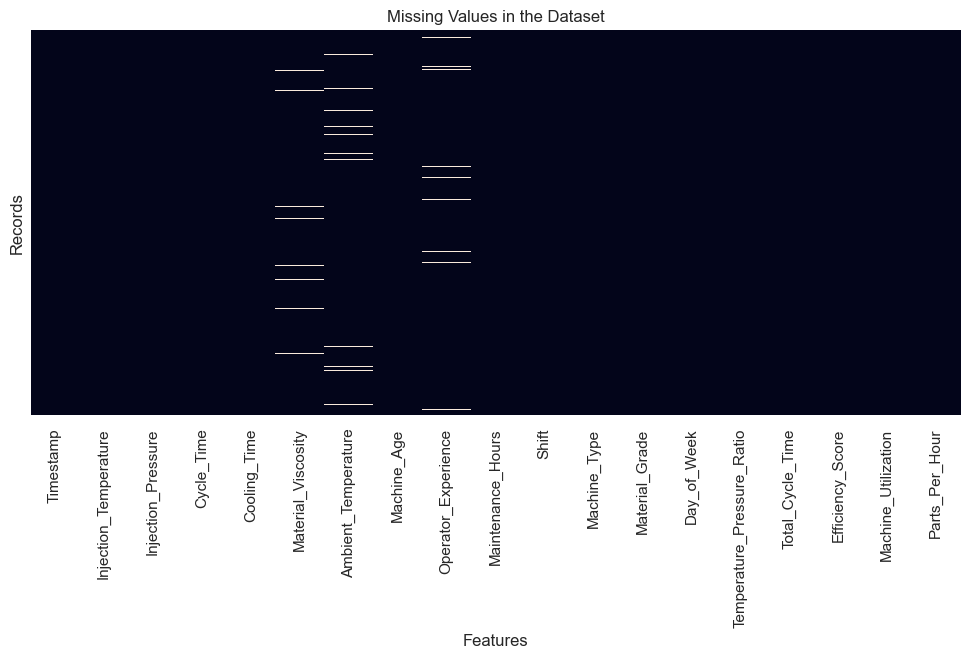

In [3]:
print("Missing Values in Each Column:")
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Values in the Dataset")
plt.xlabel("Features")
plt.ylabel("Records")
plt.show()

## Step 3: Exploratory Data Analysis (EDA)

The EDA section is designed to cover the major patterns in the dataset without creating unnecessary or repetitive visualizations.

### 3.1 Target Variable Analysis

Target Variable Summary:


count    1000.000000
mean       29.298100
std        11.955497
min         5.000000
25%        17.500000
50%        28.200000
75%        38.000000
max        68.600000
Name: Parts_Per_Hour, dtype: float64

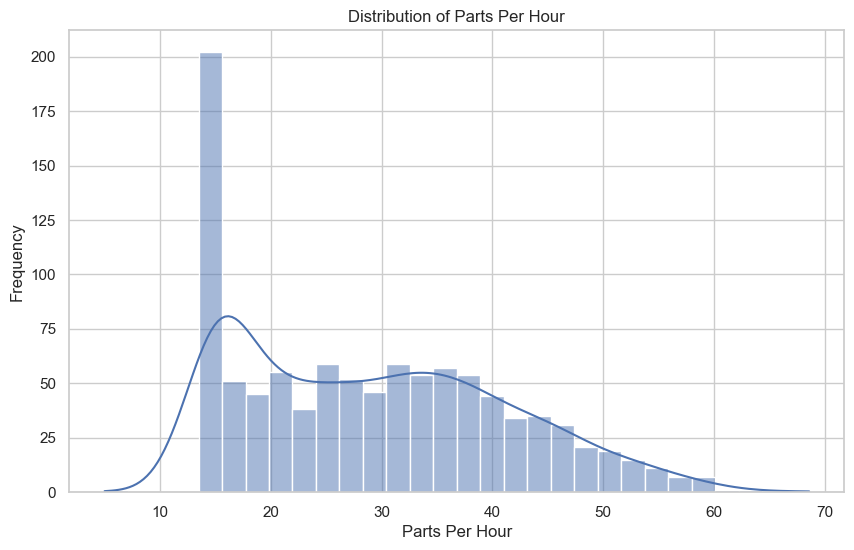

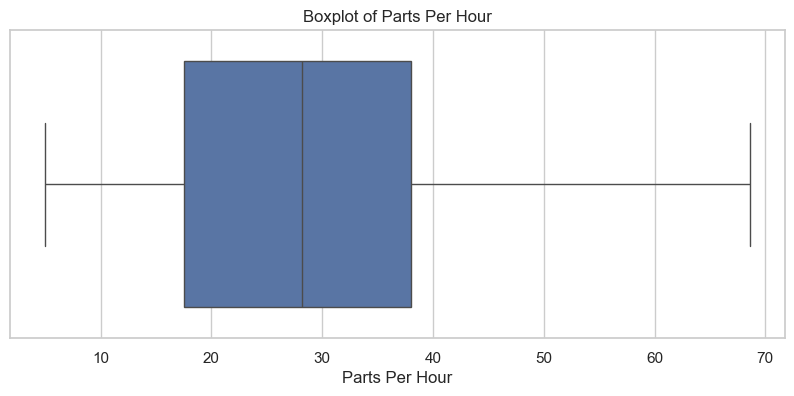

In [4]:
target = "Parts_Per_Hour"

print("Target Variable Summary:")
display(df[target].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df[target], bins=30, kde=True)
plt.title("Distribution of Parts Per Hour")
plt.xlabel("Parts Per Hour")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x=df[target])
plt.title("Boxplot of Parts Per Hour")
plt.xlabel("Parts Per Hour")
plt.show()

### Observation

`Parts_Per_Hour` shows noticeable variation across manufacturing records. The distribution is not perfectly symmetric, so both the histogram and boxplot are useful for understanding the spread of production output.

### 3.2 Numerical Feature Distributions

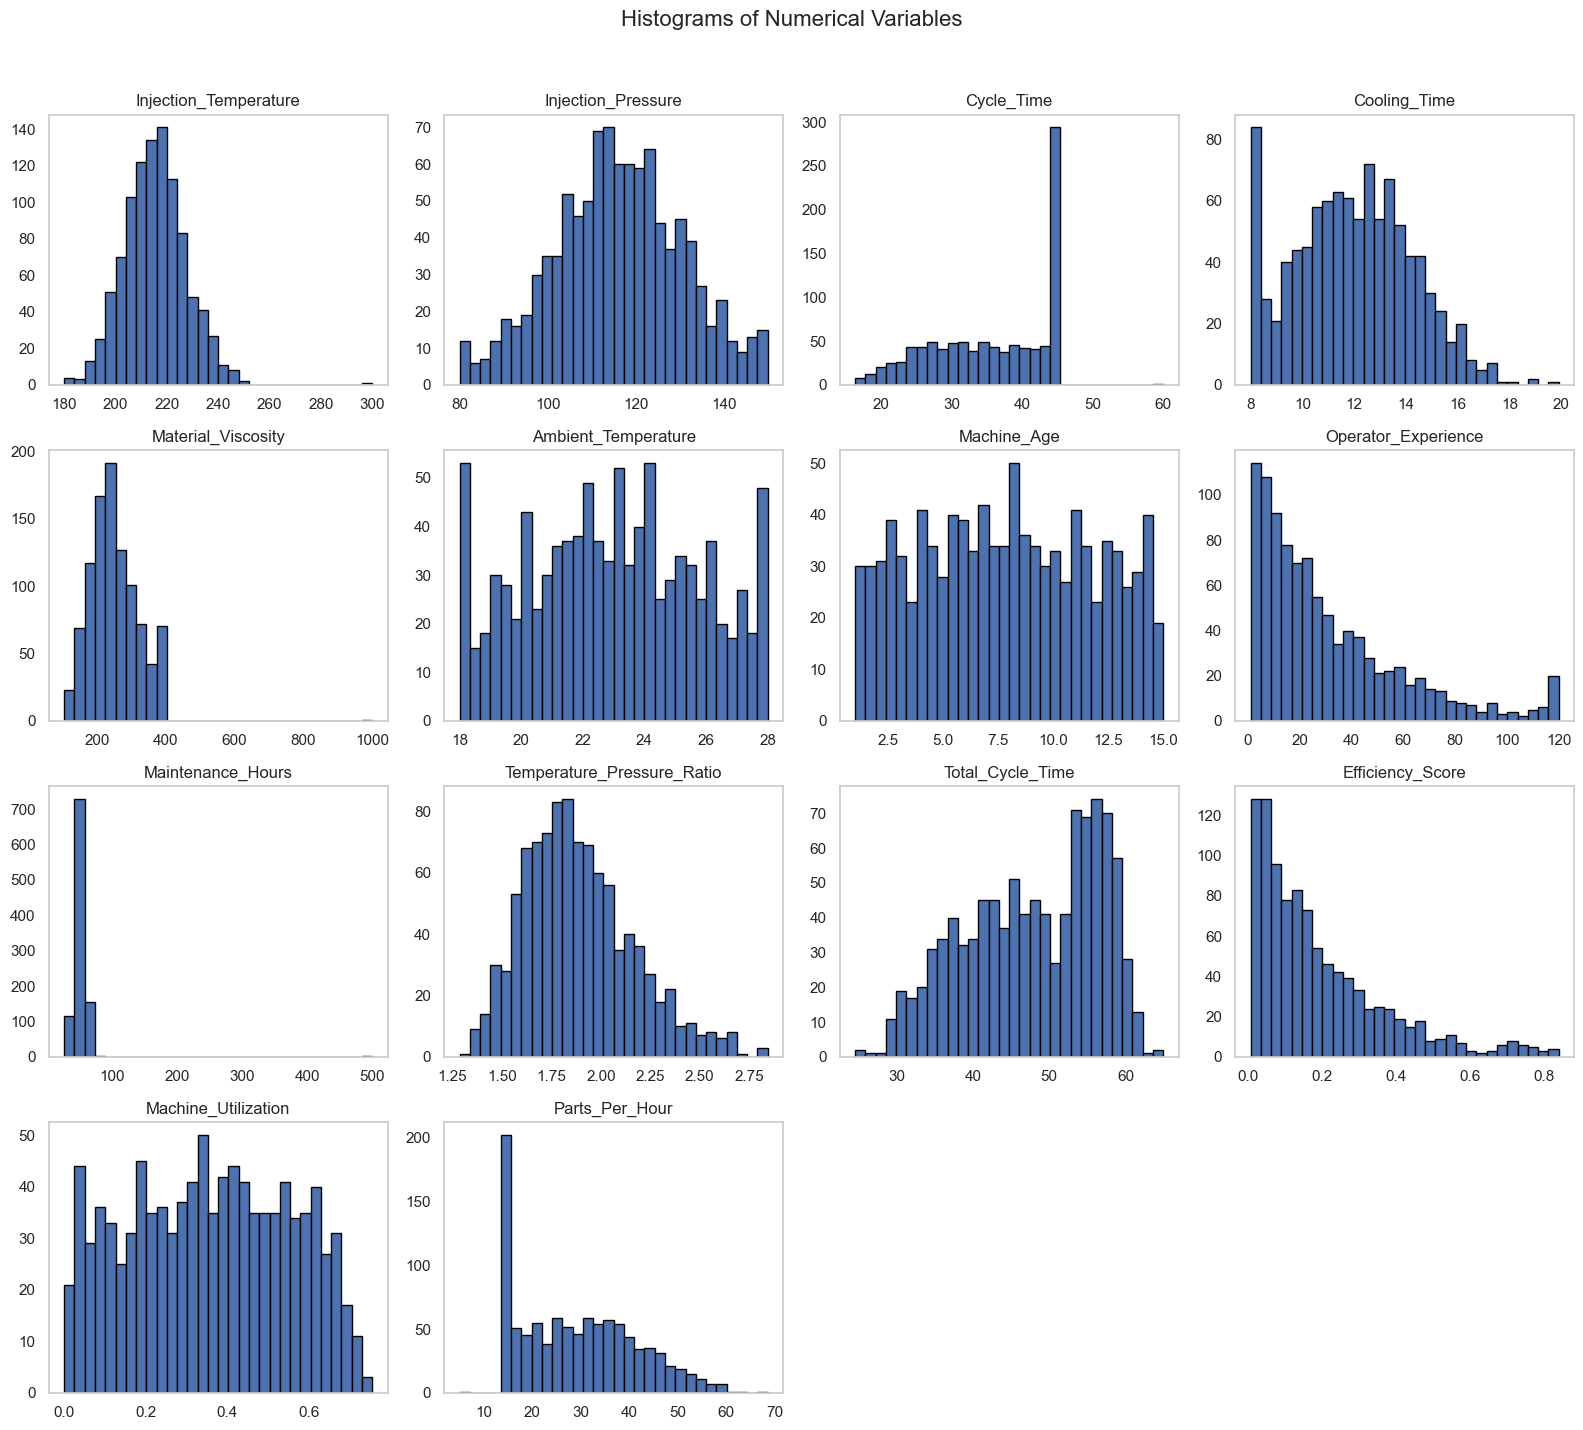

In [5]:
numerical_features_eda = df.select_dtypes(include=np.number).columns.tolist()

df[numerical_features_eda].hist(
    bins=30,
    figsize=(16, 14),
    edgecolor="black",
    grid=False
)
plt.suptitle("Histograms of Numerical Variables", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Correlation Analysis

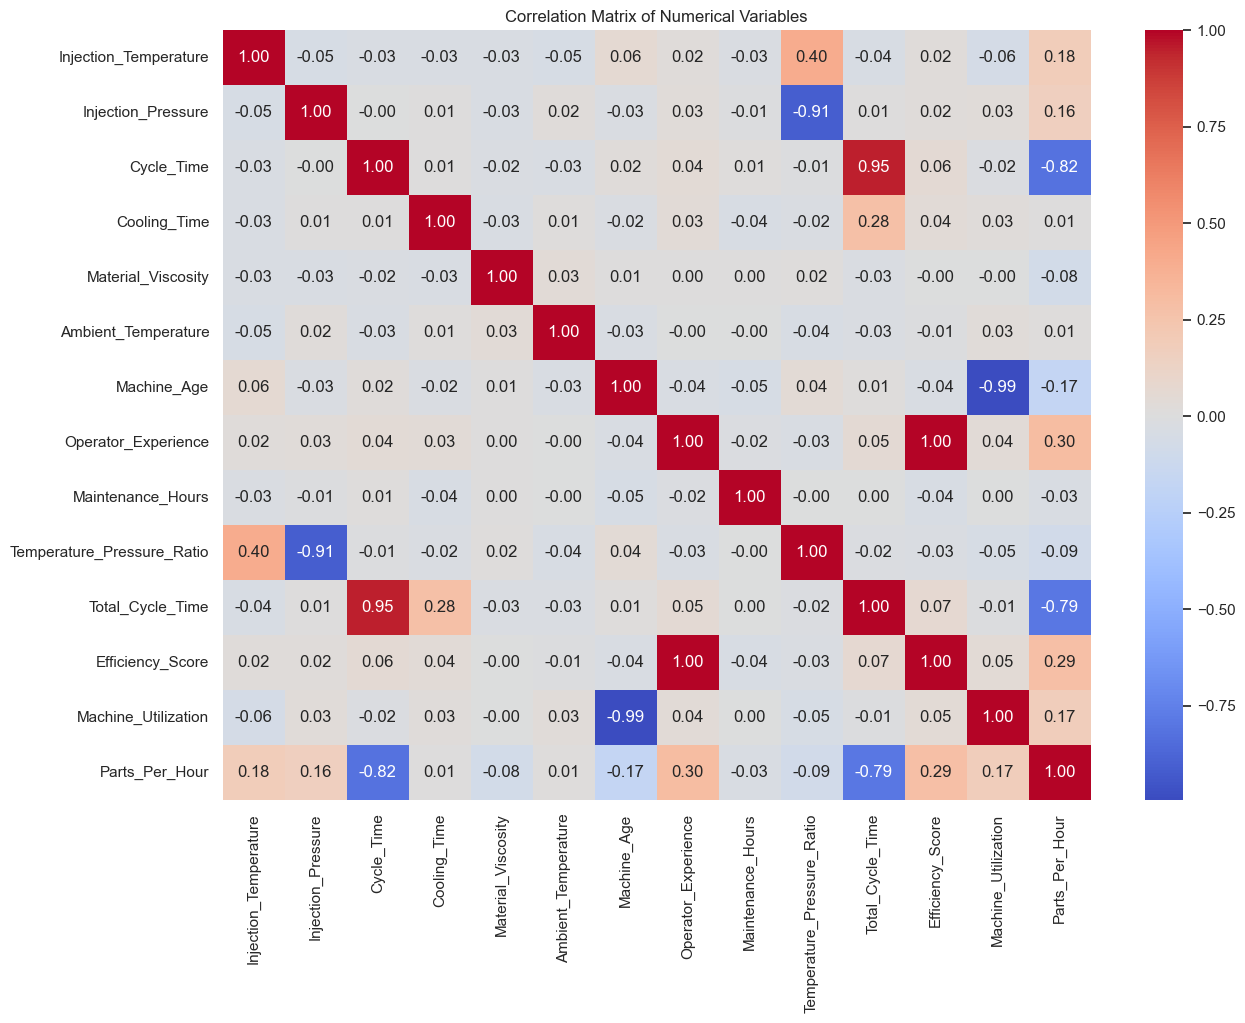

Correlation with Parts_Per_Hour:


,Correlation
Parts_Per_Hour,1.000000
Operator_Experience,0.300891
Efficiency_Score,0.286794
Injection_Temperature,0.184353
Machine_Utilization,0.174573
Injection_Pressure,0.160362
Ambient_Temperature,0.011812
Cooling_Time,0.006215
Maintenance_Hours,-0.032955
Material_Viscosity,-0.080575


In [6]:
correlation_matrix = df[numerical_features_eda].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

target_correlation = (
    correlation_matrix[target]
    .sort_values(ascending=False)
)

print("Correlation with Parts_Per_Hour:")
display(target_correlation.to_frame("Correlation"))

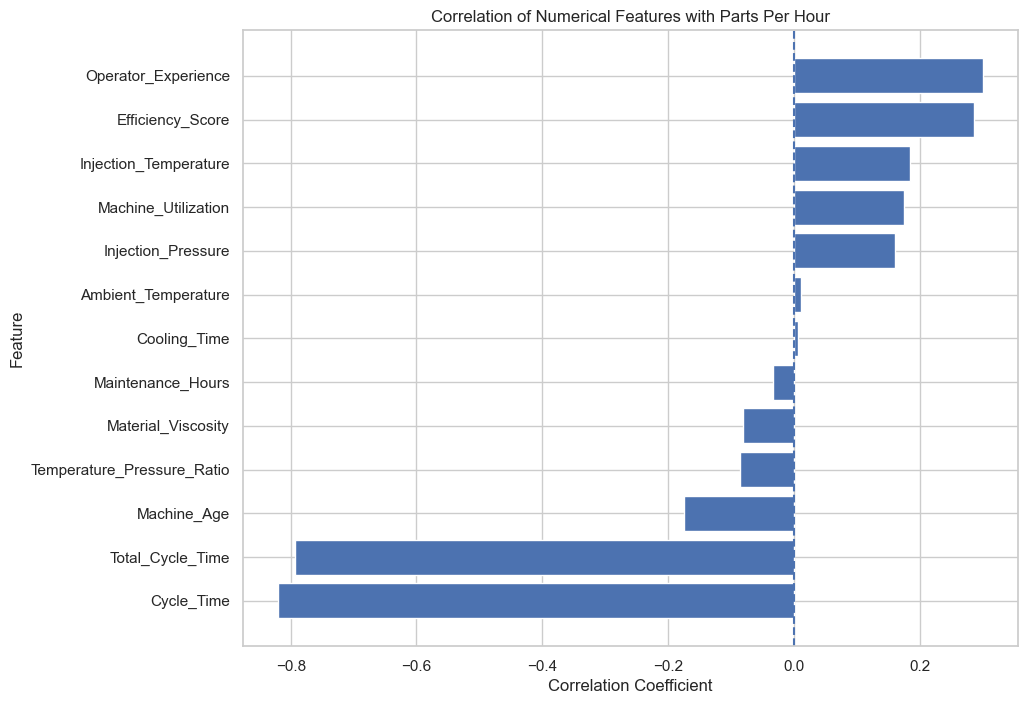

In [7]:
target_corr = (
    correlation_matrix[target]
    .drop(target)
    .sort_values()
)

plt.figure(figsize=(10, 8))
plt.barh(target_corr.index, target_corr.values)
plt.axvline(0, linestyle="--")
plt.title("Correlation of Numerical Features with Parts Per Hour")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.show()

### Key Numerical Observations

- `Cycle_Time` has the strongest negative relationship with `Parts_Per_Hour` (approximately **-0.819**).
- `Total_Cycle_Time` also has a strong negative relationship (approximately **-0.793**).
- `Operator_Experience` and `Efficiency_Score` show moderate positive relationships with output.
- `Machine_Age` shows a negative relationship with output.
- `Cycle_Time` and `Total_Cycle_Time` are highly correlated with each other, so their individual regression coefficients should be interpreted carefully.

### 3.4 Scatter Plots: Key Operational Parameters vs Output

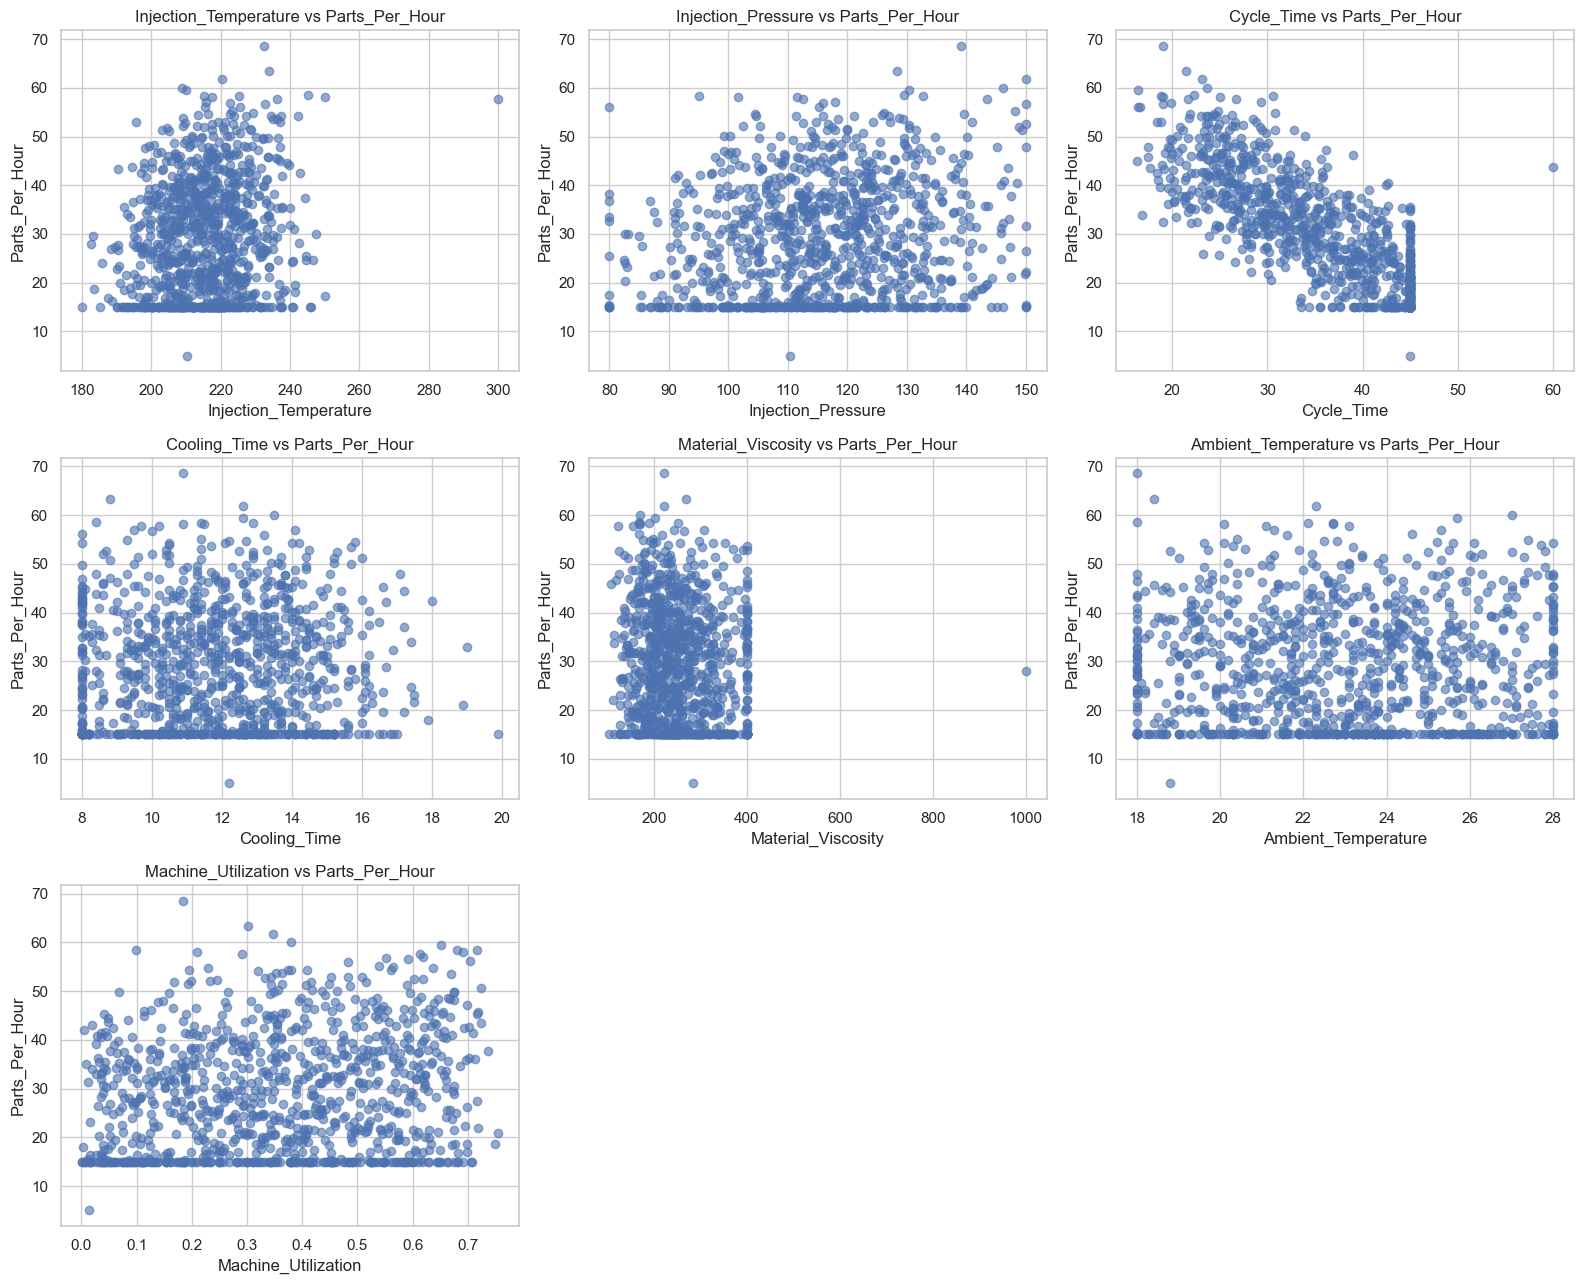

In [8]:
key_parameters = [
    "Injection_Temperature",
    "Injection_Pressure",
    "Cycle_Time",
    "Cooling_Time",
    "Material_Viscosity",
    "Ambient_Temperature",
    "Machine_Utilization"
]

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, feature in enumerate(key_parameters):
    axes[i].scatter(
        df[feature],
        df[target],
        alpha=0.6
    )
    axes[i].set_title(f"{feature} vs {target}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel(target)

for j in range(len(key_parameters), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

### 3.5 Categorical Feature Analysis

In [9]:
categorical_features = [
    "Shift",
    "Machine_Type",
    "Material_Grade",
    "Day_of_Week"
]

for feature in categorical_features:
    print(f"\n{feature} categories:")
    display(df[feature].value_counts().to_frame("Count"))


Shift categories:


,Count
Shift,
Day,517
Evening,277
Night,206



Machine_Type categories:


,Count
Machine_Type,
Type_A,384
Type_B,347
Type_C,269



Material_Grade categories:


,Count
Material_Grade,
Standard,591
Premium,210
Economy,199



Day_of_Week categories:


,Count
Day_of_Week,
Friday,168
Wednesday,155
Thursday,150
Saturday,141
Tuesday,138
Monday,136
Sunday,112


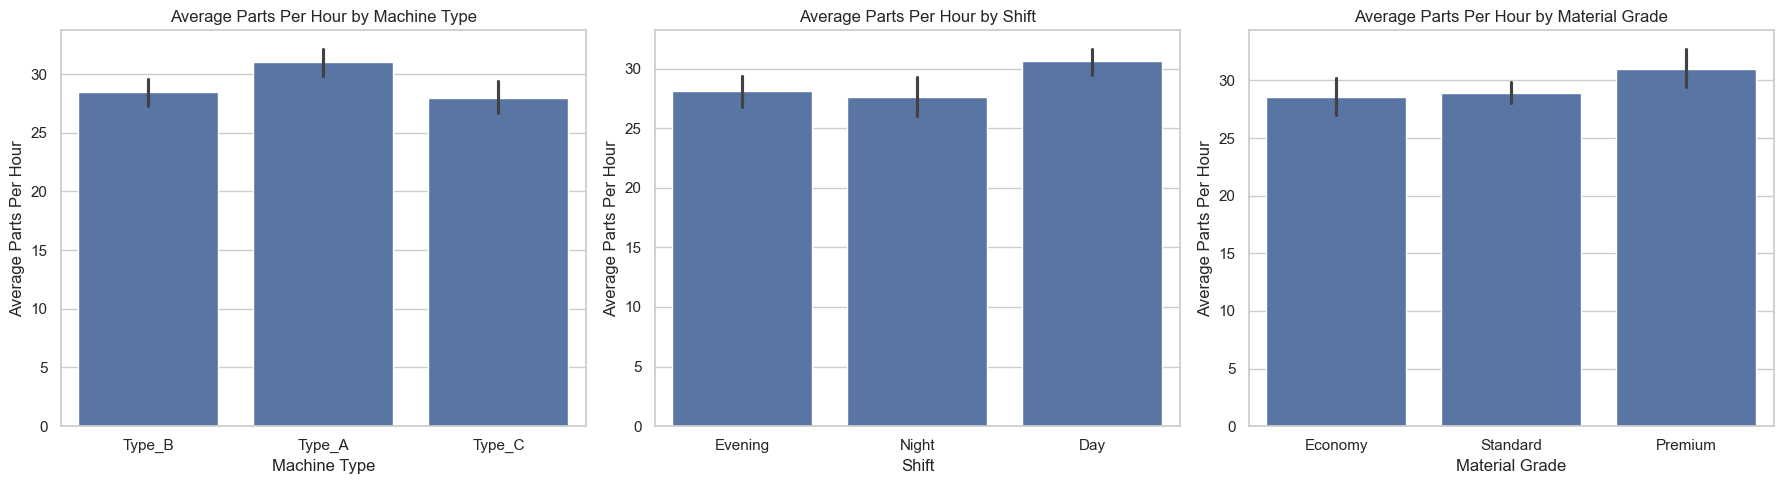

In [10]:
# Average production by major categorical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=df, x="Machine_Type", y=target, ax=axes[0])
axes[0].set_title("Average Parts Per Hour by Machine Type")
axes[0].set_xlabel("Machine Type")
axes[0].set_ylabel("Average Parts Per Hour")

sns.barplot(data=df, x="Shift", y=target, ax=axes[1])
axes[1].set_title("Average Parts Per Hour by Shift")
axes[1].set_xlabel("Shift")
axes[1].set_ylabel("Average Parts Per Hour")

sns.barplot(data=df, x="Material_Grade", y=target, ax=axes[2])
axes[2].set_title("Average Parts Per Hour by Material Grade")
axes[2].set_xlabel("Material Grade")
axes[2].set_ylabel("Average Parts Per Hour")

plt.tight_layout()
plt.show()

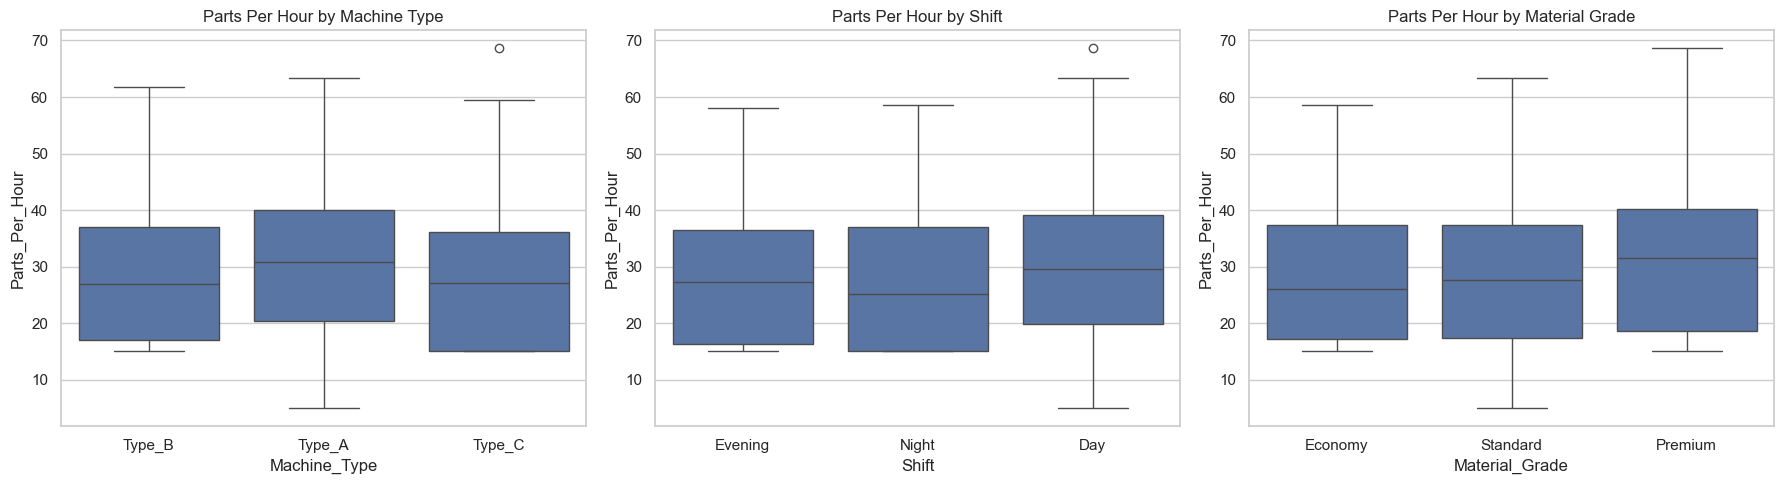

In [11]:
# Distribution of output across categorical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x="Machine_Type", y=target, ax=axes[0])
axes[0].set_title("Parts Per Hour by Machine Type")

sns.boxplot(data=df, x="Shift", y=target, ax=axes[1])
axes[1].set_title("Parts Per Hour by Shift")

sns.boxplot(data=df, x="Material_Grade", y=target, ax=axes[2])
axes[2].set_title("Parts Per Hour by Material Grade")

plt.tight_layout()
plt.show()

### Categorical EDA Observations

The categorical plots show differences in output across machine types, shifts, and material grades, while also showing substantial overlap between groups. These patterns indicate associations in the observed data rather than proof of causation.

## Step 4: Data Preprocessing and Feature Engineering

### 4.1 Timestamp Processing

The original timestamp is converted to datetime and the hour of the production record is extracted as a numerical feature. The original timestamp is then removed before modeling because a raw timestamp is not directly suitable as a Linear Regression input.

In [12]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

print("Timestamp data type:", df["Timestamp"].dtype)

df["Hour"] = df["Timestamp"].dt.hour

display(df[["Timestamp", "Hour"]].head())

df = df.drop(columns=["Timestamp"])

print("Timestamp removed.")
print("Updated dataset shape:", df.shape)

Timestamp data type: datetime64[ns]


,Timestamp,Hour
0,2023-01-01 00:00:00,0
1,2023-01-01 01:00:00,1
2,2023-01-01 02:00:00,2
3,2023-01-01 03:00:00,3
4,2023-01-01 04:00:00,4


Timestamp removed.
Updated dataset shape: (1000, 19)


### 4.2 Define Features and Target

No target-derived feature engineering is performed here. This avoids data leakage because features created directly from `Parts_Per_Hour` would use the value we are trying to predict.

In [13]:
X = df.drop(columns=[target])
y = df[target]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1000, 18)
Target shape: (1000,)


### 4.3 Train-Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (800, 18)
Testing set shape: (200, 18)


### 4.4 Preprocessing Pipeline

Numerical variables are median-imputed and standardized. Categorical variables are imputed using the most frequent category and one-hot encoded.

The preprocessing is fitted within the training pipeline, which keeps the test data separate from the fitting process.

In [15]:
# Identify feature groups
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

# Numerical preprocessing
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

# Combined preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Numerical features:
['Injection_Temperature', 'Injection_Pressure', 'Cycle_Time', 'Cooling_Time', 'Material_Viscosity', 'Ambient_Temperature', 'Machine_Age', 'Operator_Experience', 'Maintenance_Hours', 'Temperature_Pressure_Ratio', 'Total_Cycle_Time', 'Efficiency_Score', 'Machine_Utilization', 'Hour']

Categorical features:
['Shift', 'Machine_Type', 'Material_Grade', 'Day_of_Week']


## Step 5: Linear Regression Model

In [16]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### 5.1 Generate Training and Testing Predictions

In [17]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Training predictions generated.")
print("Testing predictions generated.")

print("\nFirst 10 training predictions:")
print(y_train_pred[:10])

print("\nFirst 10 testing predictions:")
print(y_test_pred[:10])

Training predictions generated.
Testing predictions generated.

First 10 training predictions:
[43.76569053 41.57827503 15.5167799  23.03746744 50.17370508 24.28017995
 23.79756419 50.5228164  46.12395395 35.21989129]

First 10 testing predictions:
[19.93598612 44.4287589  34.08753373 39.68067895 18.34945969 20.41398317
 33.50085541 14.09168252 28.02050379 32.37107296]


## Step 6: Model Evaluation and Performance Analysis

### 6.1 Training vs Testing Performance

In [18]:
def calculate_metrics(actual, predicted):
    mse = mean_squared_error(actual, predicted)
    return {
        "R²": r2_score(actual, predicted),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(actual, predicted)
    }

train_metrics = calculate_metrics(y_train, y_train_pred)
test_metrics = calculate_metrics(y_test, y_test_pred)

performance_comparison = pd.DataFrame(
    [train_metrics, test_metrics],
    index=["Training", "Testing"]
)

display(performance_comparison.round(3))

,R²,MSE,RMSE,MAE
Training,0.924,11.056,3.325,2.590
Testing,0.906,12.315,3.509,2.716


### Interpretation

Training and testing metrics should be compared rather than using the term **training accuracy/testing accuracy**, because `Parts_Per_Hour` is a continuous regression target.

- **R²** measures the proportion of variation explained by the model.
- **MAE** gives the average absolute prediction error in parts per hour.
- **RMSE** gives greater weight to larger errors.
- **MSE** is the squared-error measure used to calculate RMSE.

A relatively small gap between training and testing performance provides evidence that the model is generalizing reasonably to unseen data.

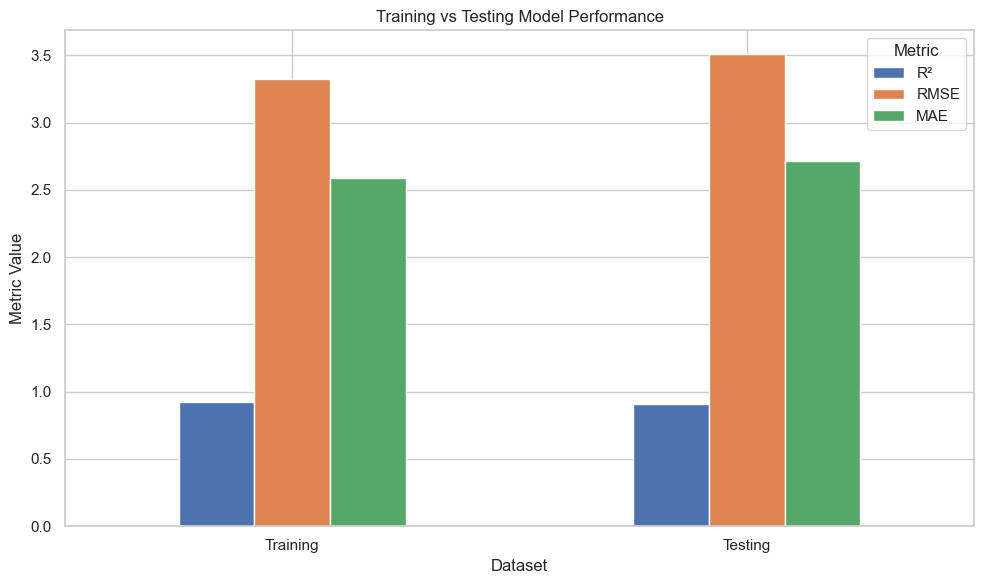

In [19]:
# Visual comparison of training and testing metrics
metrics_to_plot = ["R²", "RMSE", "MAE"]

performance_plot = performance_comparison[metrics_to_plot]

ax = performance_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Training vs Testing Model Performance")
plt.xlabel("Dataset")
plt.ylabel("Metric Value")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

### 6.2 Training: Actual vs Predicted

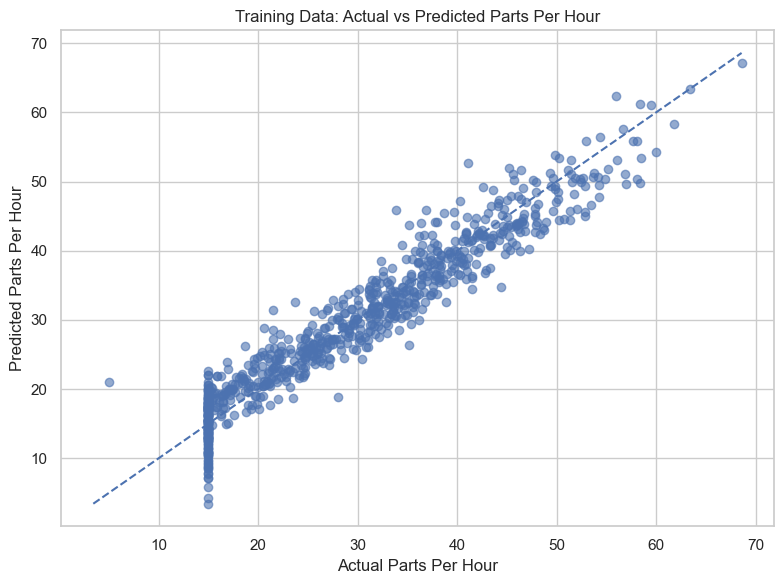

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(y_train, y_train_pred, alpha=0.6)

min_value = min(y_train.min(), y_train_pred.min())
max_value = max(y_train.max(), y_train_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Training Data: Actual vs Predicted Parts Per Hour")
plt.xlabel("Actual Parts Per Hour")
plt.ylabel("Predicted Parts Per Hour")
plt.tight_layout()
plt.show()

### 6.3 Testing: Actual vs Predicted

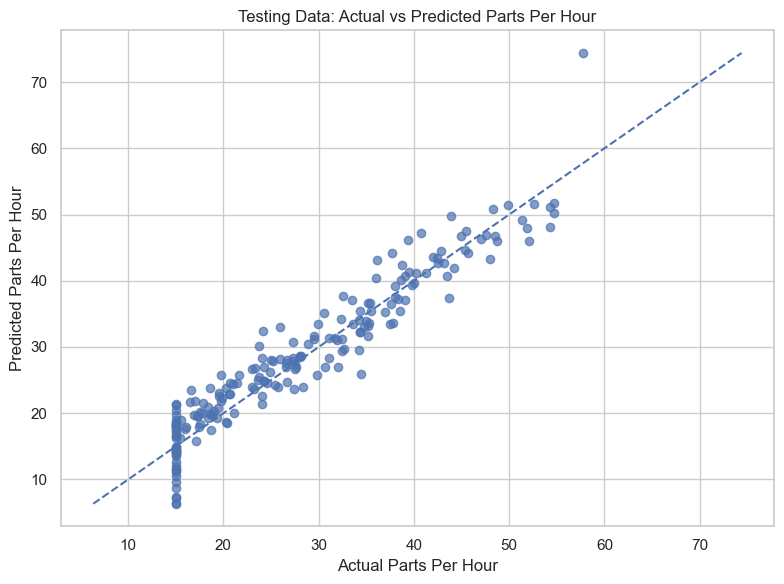

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.7)

min_value = min(y_test.min(), y_test_pred.min())
max_value = max(y_test.max(), y_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Testing Data: Actual vs Predicted Parts Per Hour")
plt.xlabel("Actual Parts Per Hour")
plt.ylabel("Predicted Parts Per Hour")
plt.tight_layout()
plt.show()

### 6.4 Training vs Testing Prediction Samples

In [22]:
train_prediction_comparison = pd.DataFrame({
    "Actual": y_train.values,
    "Predicted": y_train_pred,
    "Residual": y_train.values - y_train_pred
}).reset_index(drop=True)

test_prediction_comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred,
    "Residual": y_test.values - y_test_pred
}).reset_index(drop=True)

print("Training prediction sample:")
display(train_prediction_comparison.head(10).round(3))

print("Testing prediction sample:")
display(test_prediction_comparison.head(10).round(3))

Training prediction sample:


,Actual,Predicted,Residual
0,39.8,43.766,-3.966
1,41.5,41.578,-0.078
2,15.0,15.517,-0.517
3,19.7,23.037,-3.337
4,45.7,50.174,-4.474
5,24.7,24.280,0.420
6,26.5,23.798,2.702
7,52.7,50.523,2.177
8,47.8,46.124,1.676
9,38.9,35.220,3.680


Testing prediction sample:


,Actual,Predicted,Residual
0,18.6,19.936,-1.336
1,42.8,44.429,-1.629
2,34.2,34.088,0.112
3,40.0,39.681,0.319
4,15.0,18.349,-3.349
5,15.0,20.414,-5.414
6,33.6,33.501,0.099
7,15.0,14.092,0.908
8,25.0,28.021,-3.021
9,24.2,32.371,-8.171


### 6.5 Residual Analysis

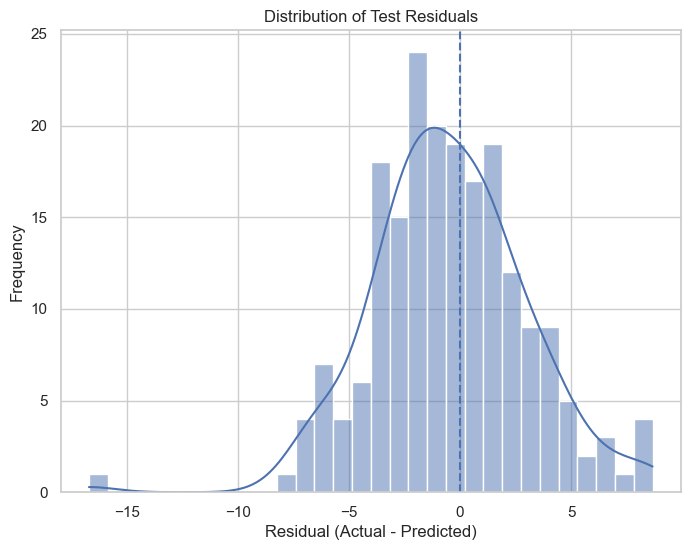

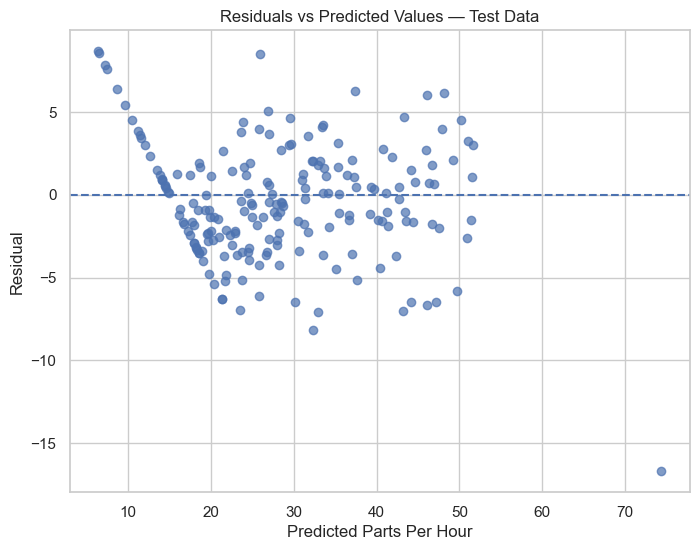

In [23]:
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_test_pred

# Test residual distribution
plt.figure(figsize=(8, 6))
sns.histplot(test_residuals, bins=30, kde=True)
plt.axvline(0, linestyle="--")
plt.title("Distribution of Test Residuals")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()

# Test residuals vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test_pred, test_residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Predicted Values — Test Data")
plt.xlabel("Predicted Parts Per Hour")
plt.ylabel("Residual")
plt.show()

### Residual Interpretation

Residuals centered around zero indicate that prediction errors are generally balanced between overprediction and underprediction. A roughly pattern-free residual plot is desirable because strong curves or funnels can indicate that the linear model is missing systematic structure.

## Step 7: Feature Coefficients and Interpretation

In [24]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["regressor"].coef_

coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_table["Absolute_Coefficient"] = coefficient_table["Coefficient"].abs()
coefficient_table = coefficient_table.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

coefficient_table_clean = coefficient_table[["Feature", "Coefficient"]].copy()
coefficient_table_clean["Coefficient"] = coefficient_table_clean["Coefficient"].round(3)

display(coefficient_table_clean)

,Feature,Coefficient
10,num__Total_Cycle_Time,-10.059
15,cat__Shift_Night,-3.961
17,cat__Machine_Type_Type_C,-3.920
18,cat__Material_Grade_Premium,3.106
11,num__Efficiency_Score,2.866
3,num__Cooling_Time,2.669
16,cat__Machine_Type_Type_B,-2.422
0,num__Injection_Temperature,2.303
6,num__Machine_Age,-2.201
25,cat__Day_of_Week_Wednesday,1.752


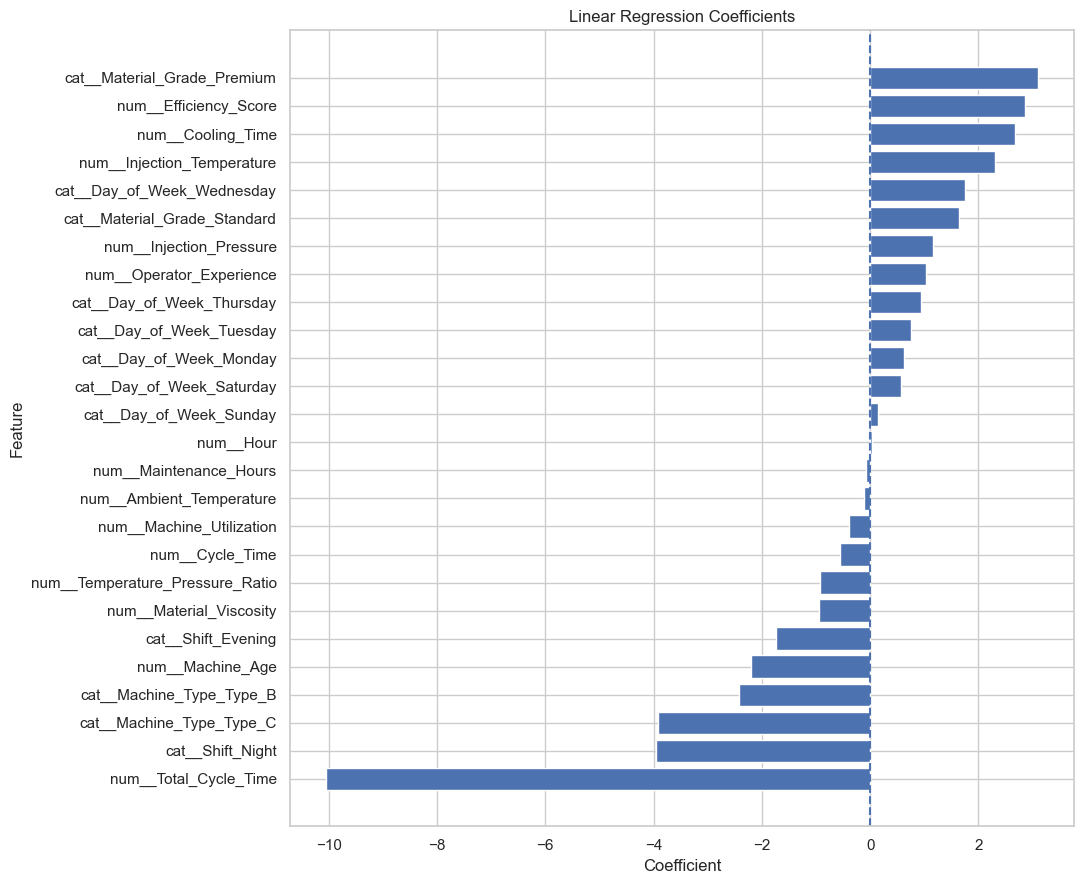

In [25]:
plot_data = coefficient_table_clean.sort_values("Coefficient")

plt.figure(figsize=(11, 9))
plt.barh(
    plot_data["Feature"],
    plot_data["Coefficient"]
)
plt.axvline(0, linestyle="--")
plt.title("Linear Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Coefficient Interpretation

Because numerical variables are standardized, a numerical coefficient represents the change in predicted `Parts_Per_Hour` associated with a one-standard-deviation increase in that feature, while holding the other model variables constant.

Categorical coefficients represent differences relative to the category omitted by one-hot encoding.

The coefficient with the largest absolute magnitude in the fitted model is `Total_Cycle_Time`, which has a negative coefficient. `Efficiency_Score` and some material/shift categories have positive coefficients, while several machine and cycle-related variables have negative coefficients.

These are **model associations, not causal effects**. In particular, the strong correlation between `Cycle_Time` and `Total_Cycle_Time` means their individual coefficients should be interpreted with care.

## Step 8: Manufacturing Insights and Recommendations

### 8.1 Key Manufacturing Insights

Based on the EDA and Linear Regression results:

1. **Cycle duration is strongly associated with production output.** `Cycle_Time` and `Total_Cycle_Time` have strong negative relationships with `Parts_Per_Hour`.
2. **Operator experience and efficiency are positively associated with output.**
3. **Production output varies across machine types, shifts, and material grades**, although the distributions overlap.
4. **The model provides reasonably close predictions on unseen test data**, as reflected by the test-set evaluation metrics.
5. **Prediction errors are generally centered around zero**, with no strong systematic residual pattern visible in the test residual plot.

### 8.2 Production Optimization Recommendations

1. **Monitor cycle duration:** Investigate unusually long cycle times because they are strongly associated with lower hourly output.
2. **Track machine-level performance:** Compare machines using consistent production KPIs and investigate persistent underperformance.
3. **Monitor shift-level output:** Use shift-level production data to identify recurring differences that may require operational review.
4. **Review material-grade performance:** Examine output and process stability across material grades before making process changes.
5. **Use the model for production planning:** Predicted output can support scheduling and expected-throughput estimates.
6. **Flag large prediction errors:** Large differences between actual and predicted output can be treated as signals for further operational investigation.

## Final Project Summary

This notebook presents a complete regression workflow for manufacturing output prediction:

**Data Loading → Data Understanding → Data Quality → EDA → Preprocessing → Train/Test Split → Linear Regression → Training & Testing Predictions → Performance Evaluation → Residual Analysis → Coefficient Interpretation → Business Insights**

The notebook intentionally stops before FastAPI/Docker deployment. Those components can be added separately as the deployment stage of the capstone project.

## Step 9: Deployment

In [26]:
import joblib

joblib.dump(model, "manufacturing_output_model.pkl")

print("Model saved successfully as manufacturing_output_model.pkl")

Model saved successfully as manufacturing_output_model.pkl
